In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("ready")

ready


In [2]:
data = {
    "name": ["Alex", "Maria", "James", "Sarah", "Tom", "Lisa"],
    "city": ["Atlanta", "New York", "Atlanta", "Chicago", "New York", "Chicago"],
    "sales": [4200, 7800, 6980, 9200, 5600, 8100],
    "months_active": [6, 12, 3, 24, 8, 18],
    "product": ["software", "hardware", "software", "hardware", "software", "hardware"]
}

df = pd.DataFrame(data)
print(df)

    name      city  sales  months_active   product
0   Alex   Atlanta   4200              6  software
1  Maria  New York   7800             12  hardware
2  James   Atlanta   6980              3  software
3  Sarah   Chicago   9200             24  hardware
4    Tom  New York   5600              8  software
5   Lisa   Chicago   8100             18  hardware


**BAR CHART**
ShowsOne value per category

Best forComparing individuals or groups

Benefit Instantly clear who is highest/lowest

Drawback Useless for showing distributions or trends over time

Real useSales per person, revenue per region

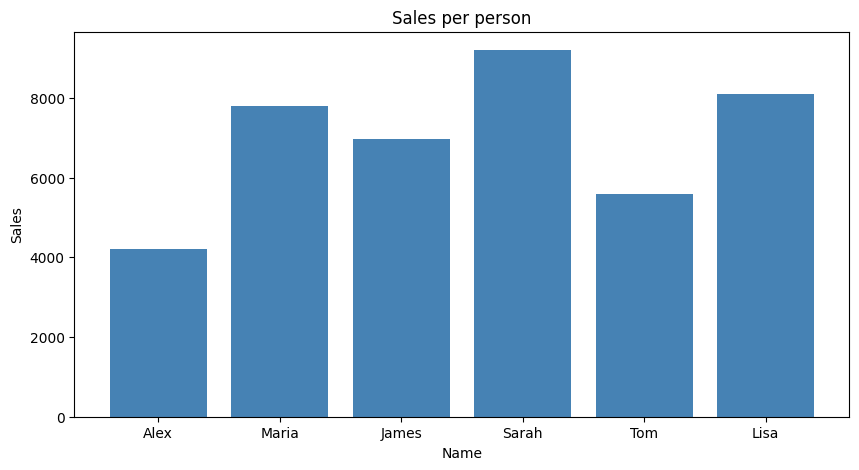

In [3]:
plt.figure(figsize=(10,5))
plt.bar(df["name"],df["sales"],color="steelblue")
plt.title("Sales per person")
plt.xlabel("Name")
plt.ylabel("Sales")
plt.show() #It renders and displays the chart. Without it, Matplotlib builds the chart in memory but never shows it.
#print for charts plt.show()

**Line Chart**
ShowsHow values change continuously

Best for Trends over time

Benefit Makes patterns and direction obvious

Drawback Misleading if data points aren't actually connected

Real use Revenue over months, model accuracy over training

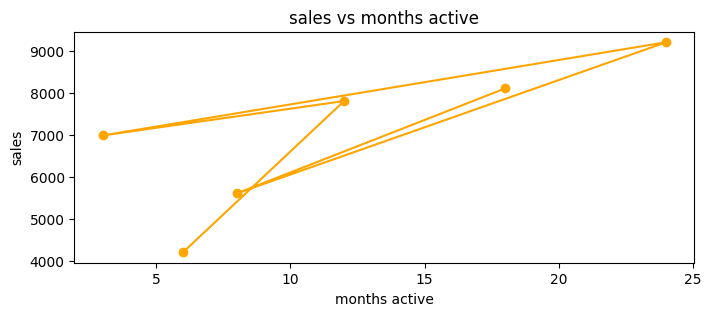

In [4]:
plt.figure(figsize=(8,3))
plt.plot(df["months_active"],df["sales"], marker="o", color = "orange")
#marker="o,s,^,x" It places a dot,square,triangle,cross at each actual data point on the line
plt.title("sales vs months active")
plt.xlabel("months active")
plt.ylabel("sales")
plt.show()

**HISTOGRAM**

ShowsHow data is distributed across ranges

Best for Understanding spread and shape of data

Benefit Reveals skew, outliers, clustering

Drawback Bin size changes the story — easy to mislead

Real use Age distribution, salary ranges, model error distribution

<function matplotlib.pyplot.show(close=None, block=None)>

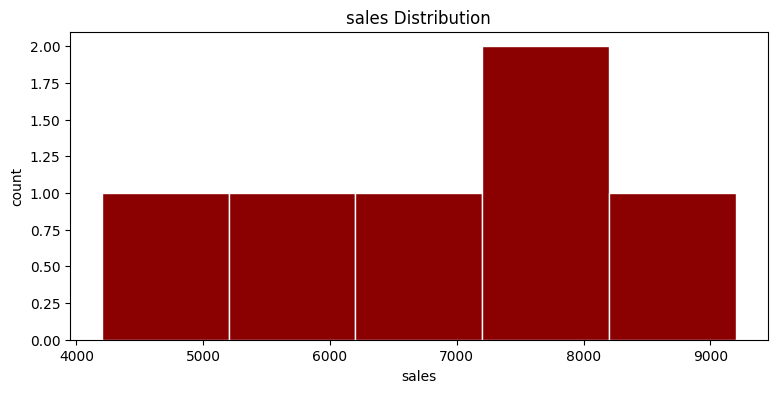

In [5]:
plt.figure(figsize=(9,4))
plt.hist(df["sales"],bins = 5, color = "darkred", edgecolor = "white")
#Bins are the buckets you split your data into.
plt.title("sales Distribution")
plt.xlabel("sales")
plt.ylabel("count")
#Count means "how many people fall in this range."
plt.show

**Scatterplots**

ShowsRelationship between two numeric variables

Best for Finding correlations

Benefit Reveals patterns no other chart can show

DrawbackHard to read with too many points

Real use does experience predict sales? Does age predict churn?

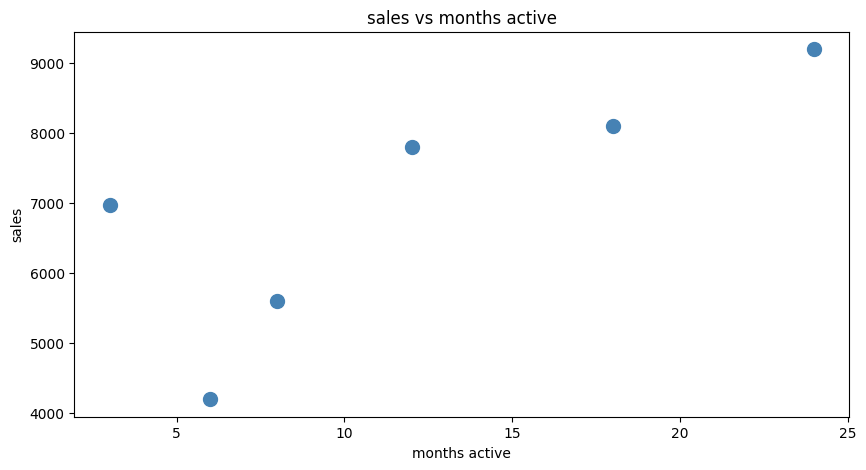

In [6]:
plt.figure(figsize=(10,5))
plt.scatter(df["months_active"],df["sales"],color="steelblue",s=100)
plt.title("sales vs months active")
plt.xlabel("months active")
plt.ylabel("sales")
plt.show()

**Heatmap Seaborn**

Shows Correlation between all numeric columns at once

Best for Feature selection before building ML models

BenefitInstantly shows which columns are related

Drawback Only works on numeric data

Real use Finding which features matter before training a model

**What correlation means:**

1 Perfect positive  as one goes up, other goes up

0.7 Strong positive relationship

0.3-0.7 Moderate relationship

0.0 No relationship

0.3 to -0.7 Moderate negative relationship

-1.0Perfect negative as one goes up, other goes down

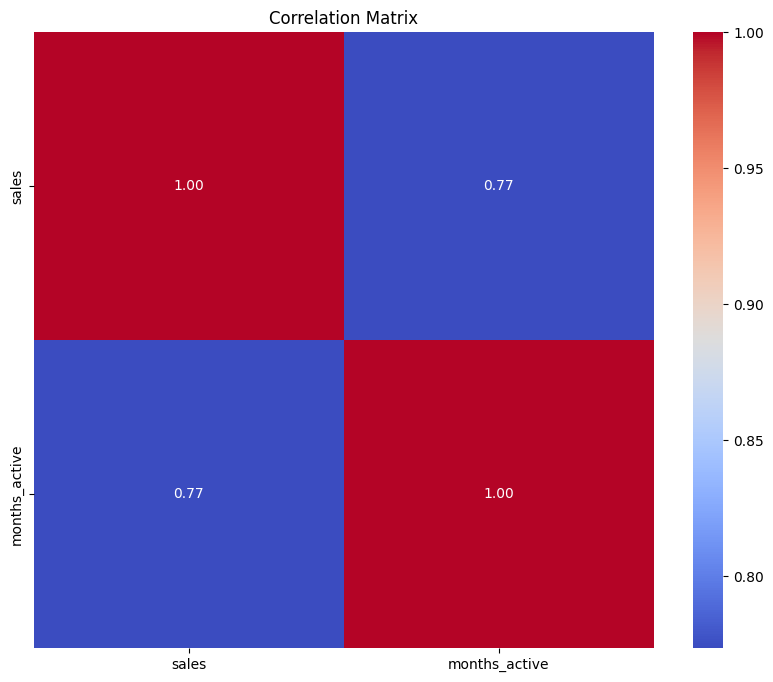

In [7]:
from numpy._core.defchararray import title
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
#df.corr(numeric_only=True) : Calculates correlation between all numeric columns. Returns a table of numbers between -1 and 1.
#annot=True : Prints the actual number inside each cell. Without this you only see colors.
#cmap="coolwarm" :1.0 = deep red (perfect positive correlation), 0.0 = white (no correlation) ,-1.0 = deep blue (perfect negative correlation)
#fmt=".2f" :formats numbers to 2 decimal places
plt.title("Correlation Matrix")
plt.show()

Comparing categories?     → Bar chart

Trend over time?          → Line chart

Distribution of one var?  → Histogram

Relationship between two? → Scatter plot

Distribution per group?   → Box plot

All correlations at once? → Heatmap

**Titanic Dataset EDA**


In [8]:
import seaborn as sns

titanic = sns.load_dataset("titanic")
print(titanic.head())
print(titanic.shape)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
(891, 15)


**BoxPlot Seaborn**

ShowsDistribution + outliers per category

Best for Comparing spread across groups

Benefit Shows median, range, and outliers in one chart

Drawback Harder to read for non-technical audiences

Real useSalary ranges by department, test scores by school

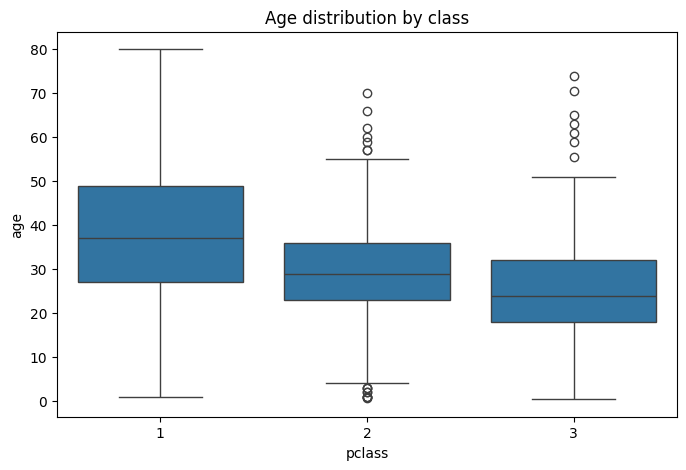

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="pclass", y="age", data=titanic)
plt.title("Age distribution by class")
plt.show()

In [10]:
#how many survived vs died?
print(titanic["survived"].value_counts())
#coloumname.valuecounts()

#missing values
print(titanic.isnull().sum())
#dataframe.isnull().sum()

survived
0    549
1    342
Name: count, dtype: int64
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


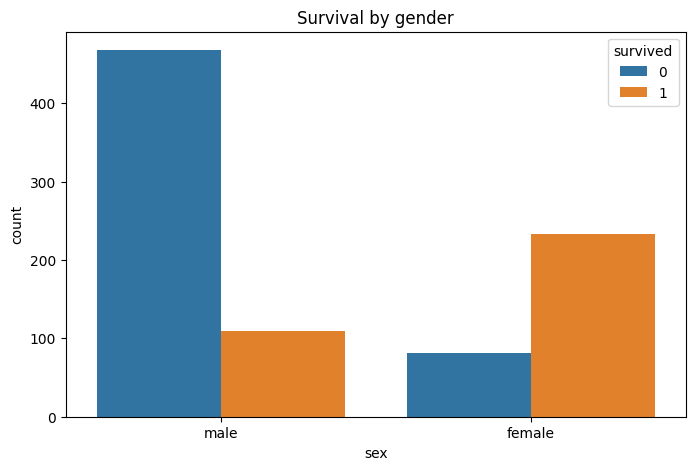

In [11]:
# Survival by gender
plt.figure(figsize=(8, 5))
sns.countplot(x="sex", hue="survived", data=titanic)
plt.title("Survival by gender")
plt.show()

#COUNT PLOT SEABORN

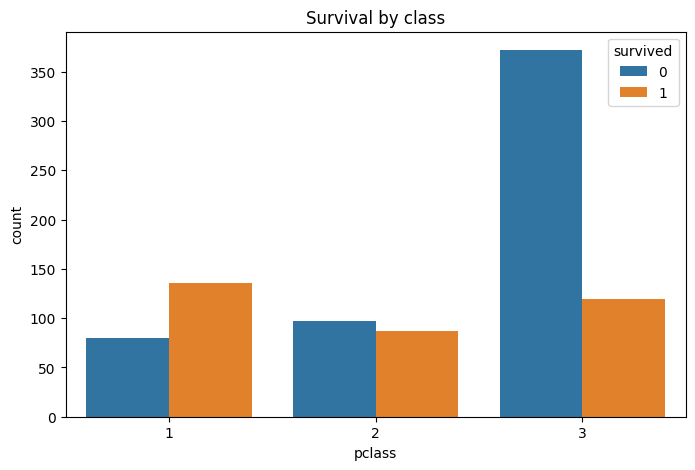

In [12]:
# Survival by passenger class
plt.figure(figsize=(8, 5))
sns.countplot(x="pclass", hue="survived", data=titanic)
plt.title("Survival by class")
plt.show()

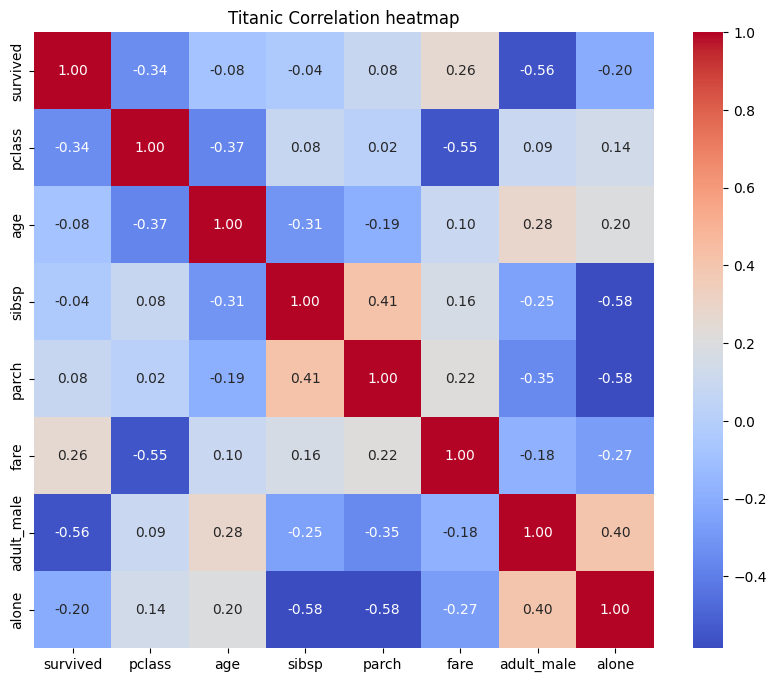

In [13]:
#Titanic Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(titanic.corr(numeric_only=True),annot=True, cmap="coolwarm",fmt=".2f")
plt.title("Titanic Correlation heatmap")
plt.show()

1. Plot age distribution as histogram
2. Bar chart — average fare per class
3. Scatter plot — age vs fare, colored by survival
4. Box plot — fare distribution by survival
5. Count plot — survival by embarked location

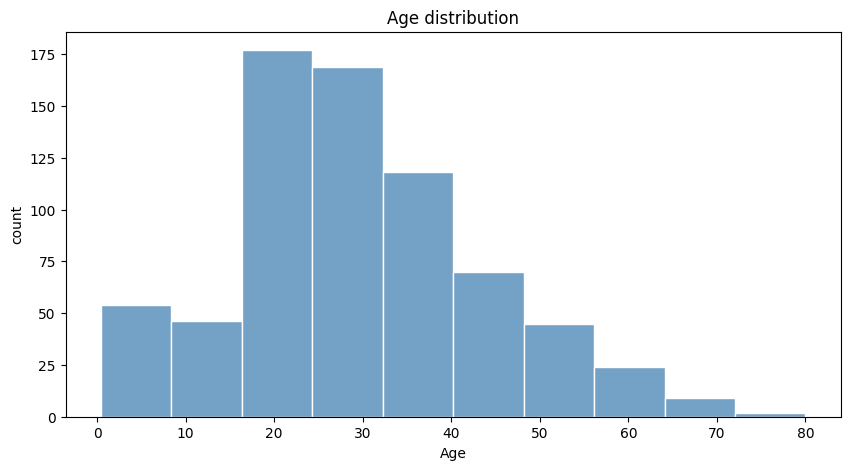

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(titanic["age"], bins=10, color = "steelblue", edgecolor = "white")
#plt.hist(titanic["age"], bins=10, color = "steelblue", edgecolor = "white")
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

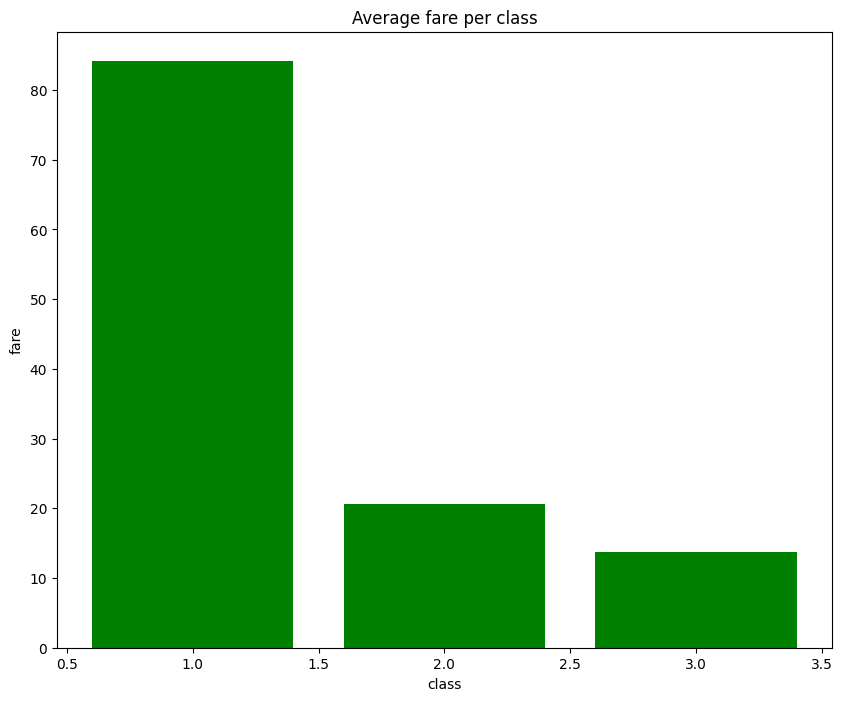

In [15]:
#average fare per class
plt.figure(figsize=(10,8))
#plt.bar(titanic["pclass"],titanic["fare"], color = "green")
#doesnt show the average fare
avg_fare = titanic.groupby("pclass")["fare"].mean()
plt.bar(avg_fare.index, avg_fare.values, color="green")
plt.title("Average fare per class")
plt.xlabel("class")
plt.ylabel("fare")
plt.show()

In [16]:
#scatterplot age vs fare, colored by survival

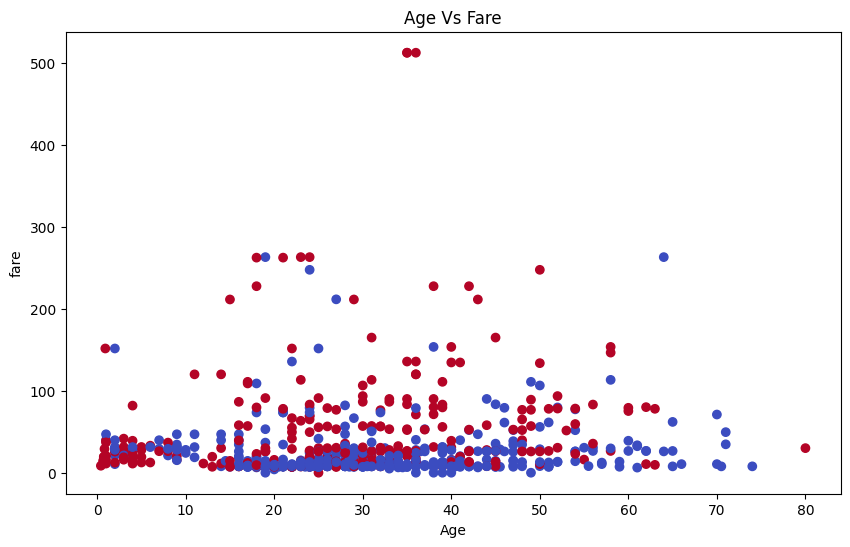

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(titanic["age"],titanic["fare"],c=titanic["survived"],cmap="coolwarm")
plt.title("Age Vs Fare")
plt.xlabel("Age")
plt.ylabel("fare")
plt.show()

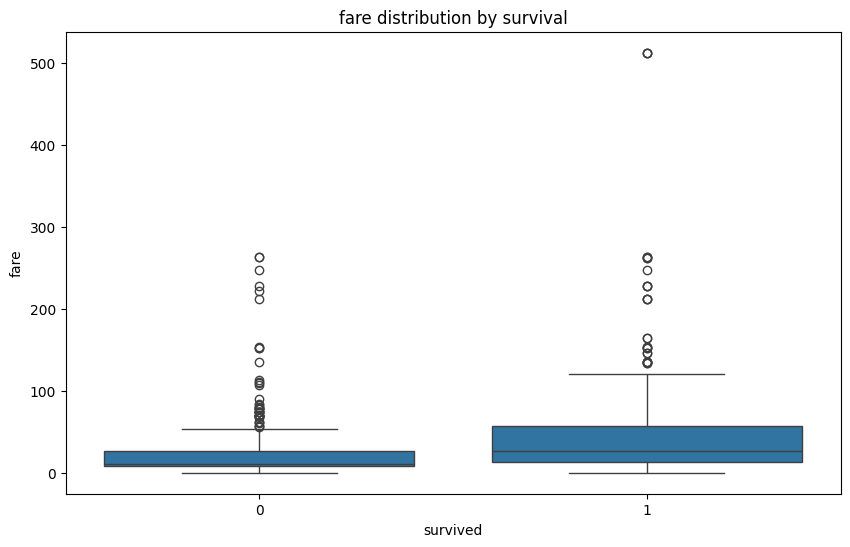

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(x="survived",y="fare", data=titanic)
plt.title("fare distribution by survival")
plt.xlabel("survived")
plt.ylabel("fare")
plt.show()

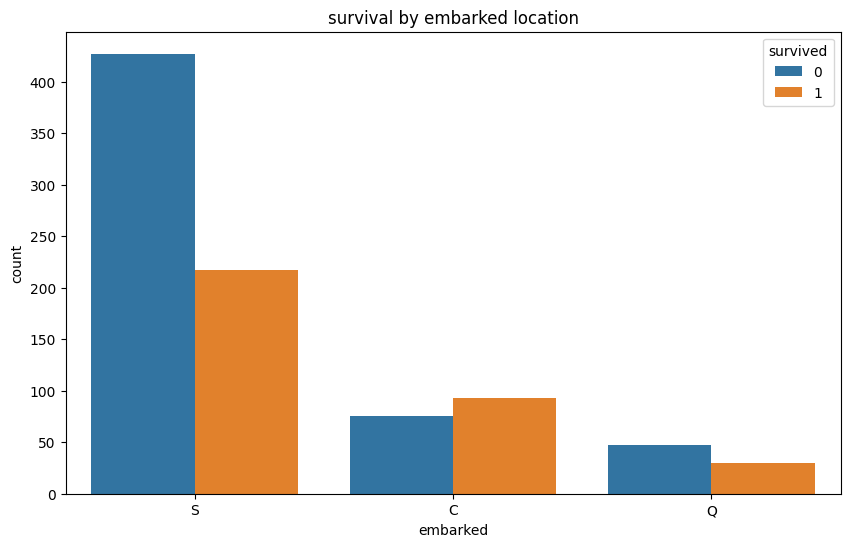

In [19]:
#survival by embarked location
plt.figure(figsize=(10,6))
sns.countplot(x="embarked",hue="survived",data=titanic)
plt.title("survival by embarked location")
plt.xlabel("embarked")
plt.ylabel("count")
plt.show()


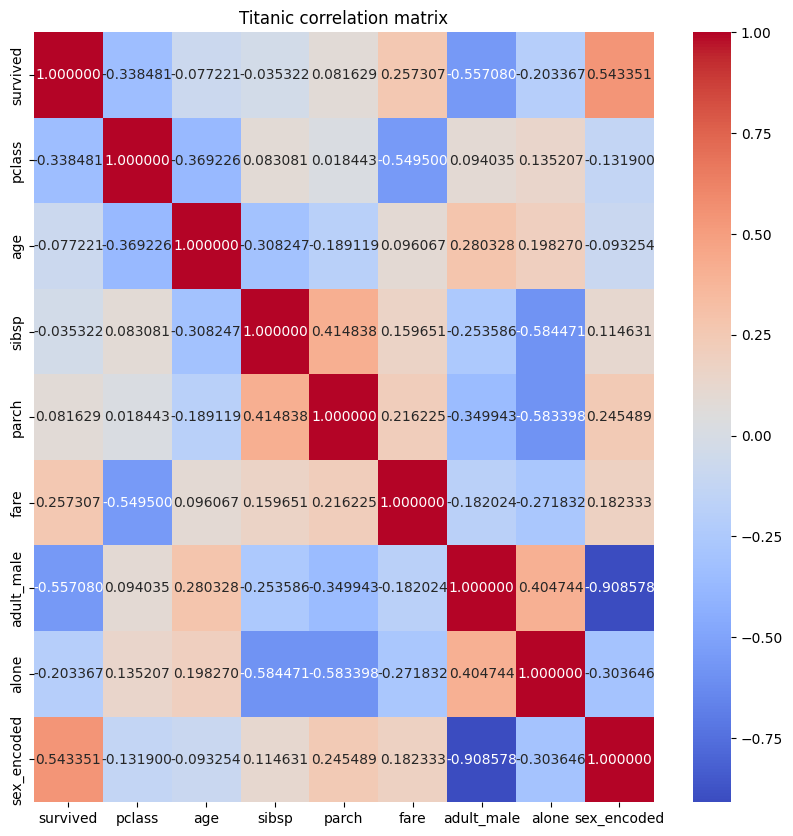

In [20]:
titanic["sex_encoded"] = titanic["sex"].map({"male": 0, "female": 1})
# include gender you'd need to convert it to numbers first as heatmap only takes numerical values
#this is example of encoding
plt.figure(figsize=(10,10))
sns.heatmap(titanic.corr(numeric_only=True),annot=True, cmap="coolwarm",fmt="-2f")
plt.title("Titanic correlation matrix")
plt.show()